In [ ]:
import echopype as ep
import matplotlib.pyplot as plt
import datetime
import numpy as np
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
#USE echopype_env on oceanica_joan folder!

#NOTES:
#.bot files for EK60 sonars are not used by echpype, not implemented
#dades de EK80?
#deadline fins després de sermana santa per jugar
# del 7 al 16 d'abril 

In [2]:

FileName = 'EK80_FM-D20201001-T212755'


In [3]:
#1. Load the raw data
# # for EK60 file
ed = ep.open_raw("../data/SUMMER/" + FileName + '.raw', sonar_model="EK80")  # for EK60 file


c:\Users\jsala\OneDrive\Desktop\Joan personal\LaPelldelCtenofor\sonificacio\oceanica\venv_echosound_py311\Lib\site-packages\echopype\convert\set_groups_ek80.py:1345: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_cal = xr.merge(ds_cal, join="outer")
c:\Users\jsala\OneDrive\Desktop\Joan personal\LaPelldelCtenofor\sonificacio\oceanica\venv_echosound_py311\Lib\site-packages\echopype\convert\set_groups_ek80.py:1345: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to n

In [9]:

print(ed.sonar)
print(ed.platform)


<xarray.DataTree 'Sonar'>
Group: /Sonar
│   Dimensions:                    (channel_all: 5, beam_group: 1)
│   Coordinates:
│     * channel_all                (channel_all) <U22 440B 'WBT 973668-15 ES120-7...
│     * beam_group                 (beam_group) <U11 44B 'Beam_group1'
│   Data variables:
│       frequency_nominal          (channel_all) float64 40B 1.2e+05 7e+04 ... 2e+05
│       transceiver_serial_number  (channel_all) <U6 120B '973668' ... '976648'
│       transducer_name            (channel_all) <U8 160B 'ES120-7C' ... 'ES200-7C'
│       transducer_serial_number   (channel_all) <U4 80B '356' '144' ... '272' '296'
│       beam_group_descr           (beam_group) <U74 296B 'contains complex backs...
│   Attributes:
│       sonar_manufacturer:      Simrad
│       sonar_model:             EK80
│       sonar_serial_number:     
│       sonar_software_name:     EK80
│       sonar_software_version:  1.12.4.0
│       sonar_type:              echosounder
└── Group: /Sonar/Beam_group

In [19]:
print(ed['sonar'])


None


In [31]:
waveform_mode="CW" #or "FM" and
encode_mode="power" #or "complex".
ed_Sv = ep.calibrate.compute_Sv(ed, waveform_mode = 'FM', encode_mode='complex')
ed_Sv = ep.consolidate.add_depth(ed_Sv)
Sv = ed_Sv["Sv"]
Sv_ch0 = ed_Sv["Sv"].sel(channel=ed_Sv.channel[0]).squeeze()

In [ ]:
print(Sv_ch0.dims)

print(Sv_ch0.coords)


('ping_time', 'range_sample')
Coordinates:
  * ping_time     (ping_time) datetime64[ns] 48B 2020-10-01T21:27:55.144985 ....
  * range_sample  (range_sample) int64 2MB 0 1 2 3 ... 253526 253527 253528
    channel       <U22 88B 'WBT 973668-15 ES120-7C'


Using vertical axis: range_sample


<Figure size 1400x600 with 0 Axes>

Text(0.5, 0, 'Time')

Text(0, 0.5, 'range_sample')

Text(0.5, 1.0, 'Echogram – EK80 FM/complex')

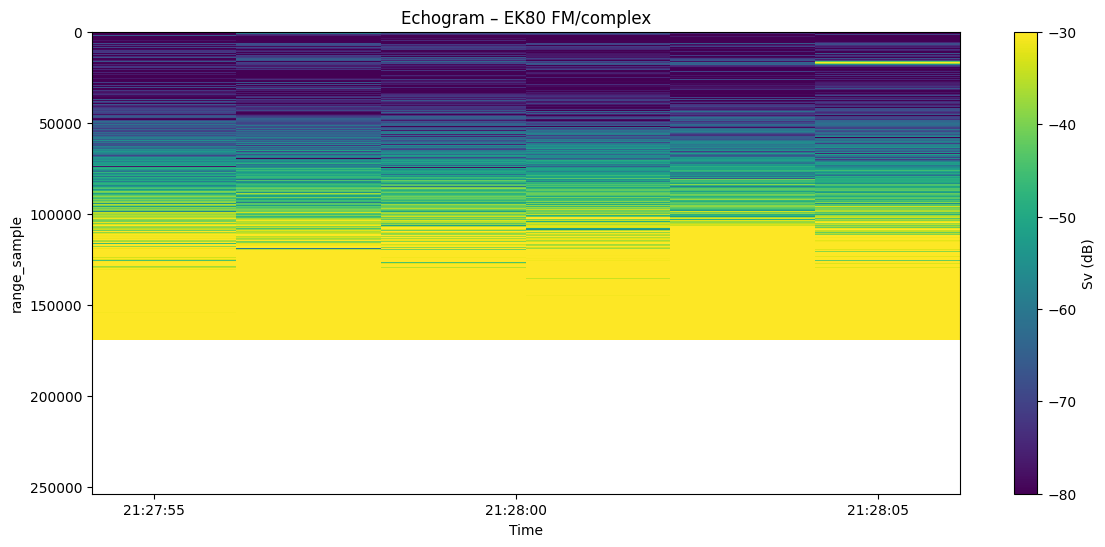

In [30]:
import matplotlib.pyplot as plt

# detect range/depth coordinate automatically
range_dim = [d for d in Sv_ch0.dims if d not in ["ping_time", "channel"]][0]

print("Using vertical axis:", range_dim)

range_coord = Sv_ch0[range_dim]

plt.figure(figsize=(14, 6))
im = plt.pcolormesh(
    Sv_ch0.ping_time,
    range_coord,
    Sv_ch0.T,
    cmap="viridis",
    vmin=-80,
    vmax=-30,
    shading="auto",
)
plt.gca().invert_yaxis()
plt.colorbar(im, label="Sv (dB)")
plt.xlabel("Time")
plt.ylabel(range_dim)
plt.title("Echogram – EK80 FM/complex")
plt.show()

<Figure size 1400x600 with 0 Axes>

Text(0.5, 0, 'Ping time')

Text(0, 0.5, 'True depth (m)')

Text(0.5, 1.0, 'EK60 Echogram — True Depth (slant range + draft correction)')

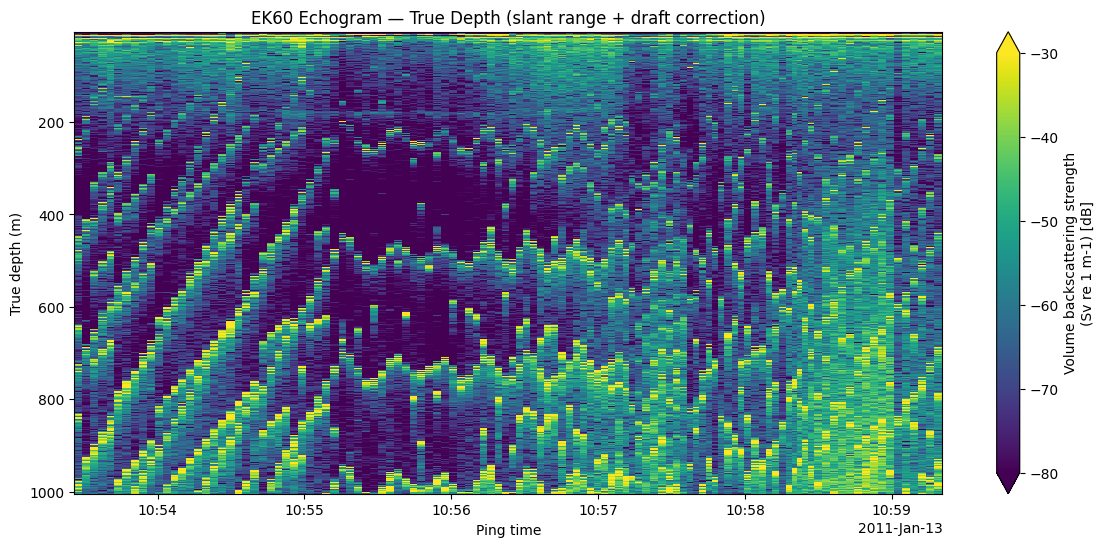

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

channel = ed_Sv.channel.values[0]

# Extract Sv and echo_range
sv = ed_Sv.Sv.sel(channel=channel)
echo_range = ed_Sv.echo_range.sel(channel=channel)

# Draft / transducer depth
draft = float(ed_Sv.water_level.values)   # = 4.5 m

# Compute true depth
true_depth = echo_range + draft

# Align arrays
sv, true_depth = xr.align(sv, true_depth)

# Attach true depth as coordinate
sv = sv.assign_coords(depth=true_depth)

# Plot
plt.figure(figsize=(14,6))
sv.plot(
    x="ping_time",
    y="depth",
    vmin=-80, vmax=-30,
    cmap="viridis"
)
plt.gca().invert_yaxis()
plt.xlabel("Ping time")
plt.ylabel("True depth (m)")
plt.title("EK60 Echogram — True Depth (slant range + draft correction)")
plt.show()


In [57]:
print(ed["Platform"].data_vars)

Data variables:
    latitude             (time1) float64 3kB -22.89 -22.89 ... -22.9 -22.9
    longitude            (time1) float64 3kB -43.2 -43.2 -43.2 ... -43.21 -43.21
    sentence_type        (time1) <U3 4kB 'GGA' 'GGA' 'GGA' ... 'GGA' 'GGA' 'GGA'
    pitch                (time2) float64 928B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    roll                 (time2) float64 928B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    vertical_offset      (time2) float64 928B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    water_level          float64 8B 4.5
    MRU_offset_x         float64 8B nan
    MRU_offset_y         float64 8B nan
    MRU_offset_z         float64 8B nan
    MRU_rotation_x       float64 8B nan
    MRU_rotation_y       float64 8B nan
    MRU_rotation_z       float64 8B nan
    position_offset_x    float64 8B nan
    position_offset_y    float64 8B nan
    position_offset_z    float64 8B nan
    transducer_offset_x  (channel) float64 8B 0.0
    transducer_offset_y  (channel) float64 8B 0.0
    transduce